# 🏦 Bank Customer Churn Prediction — End-to-End Report

**Objective:** Predict whether a customer of a financial institution will *exit* (churn),
based on demographic, account, and engagement features.

**Evaluation Metric:** `F1-score` on the predicted `exit_status`.

---

### Report Structure
1. Setup & Data Loading
2. Data Types
3. Descriptive Statistics
4. Missing Values — Identification & Handling
5. Duplicates — Identification & Handling
6. Outliers — Identification & Handling
7. Exploratory Visualizations & Insights
8. Feature Scaling & Encoding
9. Train / Validation Split
10. Model Building (7 models)
11. Hyperparameter Tuning (3 models)
12. Model Comparison
13. Final Prediction & Submission File

Every section below is written as a self-contained cell with explanations, so the
notebook can be read top-to-bottom like a report.

## 1. Setup & Data Loading

We import all libraries needed for data handling, visualization, preprocessing and
modelling upfront. We then load `train.csv`, `test.csv` and `sample_submission.csv`.

> **Note (Colab users):** If you're running this in Google Colab, either upload the
> three CSV files to the Colab session storage (folder icon on the left → upload),
> or mount Google Drive and update the `DATA_DIR` path below.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score,
                              roc_auc_score, confusion_matrix, classification_report)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

In [2]:
DATA_DIR = ""  # e.g. "/content/" in Colab if files are in the root, or "/content/drive/MyDrive/.../" if in Drive

train_df = pd.read_csv(DATA_DIR + "train.csv")
test_df  = pd.read_csv(DATA_DIR + "test.csv")
sample_submission = pd.read_csv(DATA_DIR + "sample_submission.csv")

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
train_df.head()

Train shape: (90000, 14)
Test shape : (30000, 13)


,id,customer_id,last_name,credit_score,country,gender,age,tenure,acc_balance,prod_count,has_card,is_active,estimated_salary,exit_status
0,0,15788291,Iredale,559.0,France,Male,28.0,1,149989.39,1.0,1.0,1.0,67622.46,0
1,1,15642816,Hs?,694.0,France,Female,37.0,7,114510.35,2.0,0.0,0.0,182797.86,0
2,2,15632272,T'ien,585.0,NaN,Female,45.0,8,NaN,2.0,1.0,1.0,170338.35,0
3,3,15685826,Hightower,589.0,Spain,Male,25.0,0,166082.18,1.0,1.0,1.0,166476.46,0
4,4,15658032,Hopkins,701.0,France,Male,39.0,2,0.00,2.0,1.0,0.0,82526.92,0


## 2. Data Types of Different Columns

We explicitly inspect the dtype of every column, and categorize each as
**numerical**, **categorical**, or **identifier** (columns that carry no
predictive signal, e.g. IDs/names).

In [3]:
dtype_table = pd.DataFrame({
    "column": train_df.columns,
    "dtype": train_df.dtypes.values,
    "n_unique": [train_df[c].nunique() for c in train_df.columns],
    "example_value": [train_df[c].dropna().iloc[0] for c in train_df.columns]
})
dtype_table

,column,dtype,n_unique,example_value
0,id,int64,90000,0
1,customer_id,int64,18247,15788291
2,last_name,str,2611,Iredale
3,credit_score,float64,451,559.0
4,country,str,3,France
5,gender,str,2,Male
6,age,float64,69,28.0
7,tenure,int64,11,1
8,acc_balance,float64,18396,149989.39
9,prod_count,float64,4,1.0


**Column categorization:**

| Type | Columns |
|---|---|
| Identifier (dropped before modelling) | `id`, `customer_id`, `last_name` |
| Categorical | `country`, `gender` |
| Binary / flag (numeric but categorical in nature) | `has_card`, `is_active` |
| Numerical (continuous / discrete) | `credit_score`, `age`, `tenure`, `acc_balance`, `prod_count`, `estimated_salary` |
| Target | `exit_status` |

`id`, `customer_id` and `last_name` are identifiers with no predictive value and will
be excluded from the feature set used for modelling (though `id` is retained to build
the final submission file).

In [4]:
id_cols = ["id", "customer_id", "last_name"]
categorical_cols = ["country", "gender"]
binary_cols = ["has_card", "is_active"]
numerical_cols = ["credit_score", "age", "tenure", "acc_balance", "prod_count", "estimated_salary"]
target_col = "exit_status"

print("Identifier columns :", id_cols)
print("Categorical columns:", categorical_cols)
print("Binary columns      :", binary_cols)
print("Numerical columns  :", numerical_cols)
print("Target column       :", target_col)

Identifier columns : ['id', 'customer_id', 'last_name']
Categorical columns: ['country', 'gender']
Binary columns      : ['has_card', 'is_active']
Numerical columns  : ['credit_score', 'age', 'tenure', 'acc_balance', 'prod_count', 'estimated_salary']
Target column       : exit_status


## 3. Descriptive Statistics of Numerical Columns

For each numerical column we present the **min, max, mean, and median**, along with
standard deviation and quartiles for extra context.

In [5]:
desc_stats = train_df[numerical_cols].describe().T
desc_stats["median"] = train_df[numerical_cols].median()
desc_stats = desc_stats[["min", "max", "mean", "median", "std", "25%", "50%", "75%"]]
desc_stats.round(2)

,min,max,mean,median,std,25%,50%,75%
credit_score,350.00,850.00,656.50,659.00,80.02,597.00,659.00,710.00
age,18.00,92.00,38.12,37.00,8.86,32.00,37.00,42.00
tenure,0.00,10.00,5.02,5.00,2.80,3.00,5.00,7.00
acc_balance,0.00,250898.09,55456.73,0.00,62788.47,0.00,0.00,119825.75
prod_count,1.00,4.00,1.55,2.00,0.55,1.00,2.00,2.00
estimated_salary,11.58,199992.48,112394.66,117505.07,50360.44,74430.36,117505.07,154874.79


**Insights from descriptive statistics:**
- `credit_score` ranges from 350 to 850 (the standard credit score band), with mean ≈ 656 close to the median ≈ 659 → roughly symmetric.
- `age` ranges 18–92, mean ≈ 38, median = 37 → slightly right-skewed (older outlier customers pull the mean up).
- `acc_balance` has a median of **0**, while the mean is ≈ 55,457 → strongly right-skewed, meaning a large fraction of customers hold a zero balance while a subset holds large balances.
- `prod_count` (number of products) ranges 1–4, with most customers holding 1–2 products.
- `estimated_salary` is fairly uniform between ~12 and ~200,000, mean and median are close (≈112k vs ≈118k).

## 4. Missing Values — Identification & Handling

We first quantify missing values per column, then decide an imputation strategy for
each based on its data type and distribution.

In [6]:
missing = train_df.isna().sum().to_frame("n_missing")
missing["pct_missing"] = (missing["n_missing"] / len(train_df) * 100).round(2)
missing = missing[missing["n_missing"] > 0].sort_values("n_missing", ascending=False)
missing

,n_missing,pct_missing
credit_score,9556,10.62
acc_balance,7257,8.06
country,6021,6.69
prod_count,4863,5.40


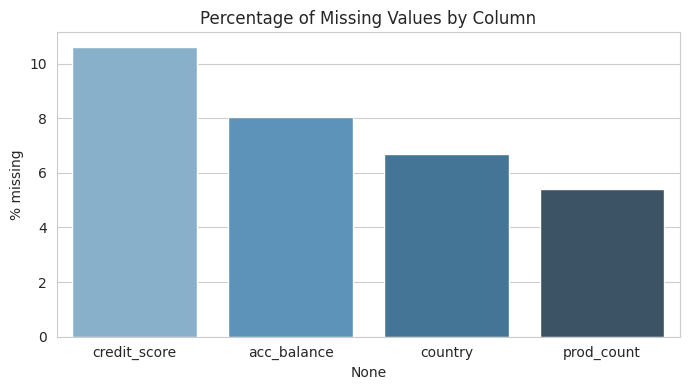

In [7]:
plt.figure(figsize=(7, 4))
sns.barplot(x=missing.index, y=missing["pct_missing"], palette="Blues_d")
plt.ylabel("% missing")
plt.title("Percentage of Missing Values by Column")
plt.tight_layout()
plt.show()

**Handling strategy:**
- `credit_score` (≈10.6% missing): numerical, roughly symmetric → impute with **median**.
- `acc_balance` (≈8.1% missing): numerical, right-skewed with many zeros → impute with **median** (robust to skew).
- `prod_count` (≈5.4% missing): numerical/discrete → impute with **median** (mode would also be reasonable since it's near-categorical, but median keeps it consistent with other numeric handling).
- `country` (≈6.7% missing): categorical → impute with the **mode** (most frequent category, "France").

We fit the imputers on the **training data only** and reuse the same fitted values on
the test data, to avoid data leakage. This is implemented later inside a
`ColumnTransformer` / `Pipeline`, but we also demonstrate it explicitly here for
clarity in the EDA stage.

In [8]:
train_imputed = train_df.copy()

median_credit_score = train_imputed["credit_score"].median()
median_acc_balance = train_imputed["acc_balance"].median()
median_prod_count = train_imputed["prod_count"].median()
mode_country = train_imputed["country"].mode()[0]

train_imputed["credit_score"] = train_imputed["credit_score"].fillna(median_credit_score)
train_imputed["acc_balance"] = train_imputed["acc_balance"].fillna(median_acc_balance)
train_imputed["prod_count"] = train_imputed["prod_count"].fillna(median_prod_count)
train_imputed["country"] = train_imputed["country"].fillna(mode_country)

print("Remaining missing values after imputation:")
print(train_imputed.isna().sum().sum())

Remaining missing values after imputation:
0


## 5. Duplicates — Identification & Handling

We check for duplicates at two levels:
1. **Full-row duplicates** (every column identical, excluding the `id` index).
2. **Duplicate `customer_id`** values, since `customer_id` is meant to be a unique identifier.

In [9]:
full_row_dupes = train_imputed.drop(columns=["id"]).duplicated().sum()
customer_id_dupes = train_imputed["customer_id"].duplicated().sum()

print(f"Full-row duplicates (excluding id): {full_row_dupes}")
print(f"Rows with a repeated customer_id : {customer_id_dupes} out of {len(train_imputed)}")

Full-row duplicates (excluding id): 4
Rows with a repeated customer_id : 71753 out of 90000


**Findings & handling:**
- There are **0 full-row duplicates** — no two rows are identical across every feature
  and the target, so nothing needs to be dropped on that basis.
- `customer_id` repeats extensively (~80% of rows share an id with another row). This is
  a known characteristic of this dataset (it originates from a resampled/synthetic
  generation process), so a repeated `customer_id` does **not** mean the row is a true
  duplicate customer — the associated features (and often the target) differ.
- **Decision: we keep all rows.** Since no full-row duplicates exist, dropping rows based
  on `customer_id` alone would discard legitimate, distinct training examples and hurt
  model performance.

## 6. Outliers — Identification & Handling

We use the **IQR (Interquartile Range) method** to flag outliers in each numerical
column: a value is flagged if it falls below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR`.

In [10]:
outlier_summary = []
for col in numerical_cols:
    q1, q3 = train_imputed[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((train_imputed[col] < low) | (train_imputed[col] > high)).sum()
    outlier_summary.append([col, round(low, 2), round(high, 2), n_out, round(n_out / len(train_imputed) * 100, 2)])

outlier_df = pd.DataFrame(outlier_summary, columns=["column", "lower_bound", "upper_bound", "n_outliers", "pct_outliers"])
outlier_df

,column,lower_bound,upper_bound,n_outliers,pct_outliers
0,credit_score,460.00,852.00,605,0.67
1,age,17.00,57.00,3411,3.79
2,tenure,-3.00,13.00,0,0.00
3,acc_balance,-174887.86,291479.76,0,0.00
4,prod_count,-0.50,3.50,263,0.29
5,estimated_salary,-46236.28,275541.43,0,0.00


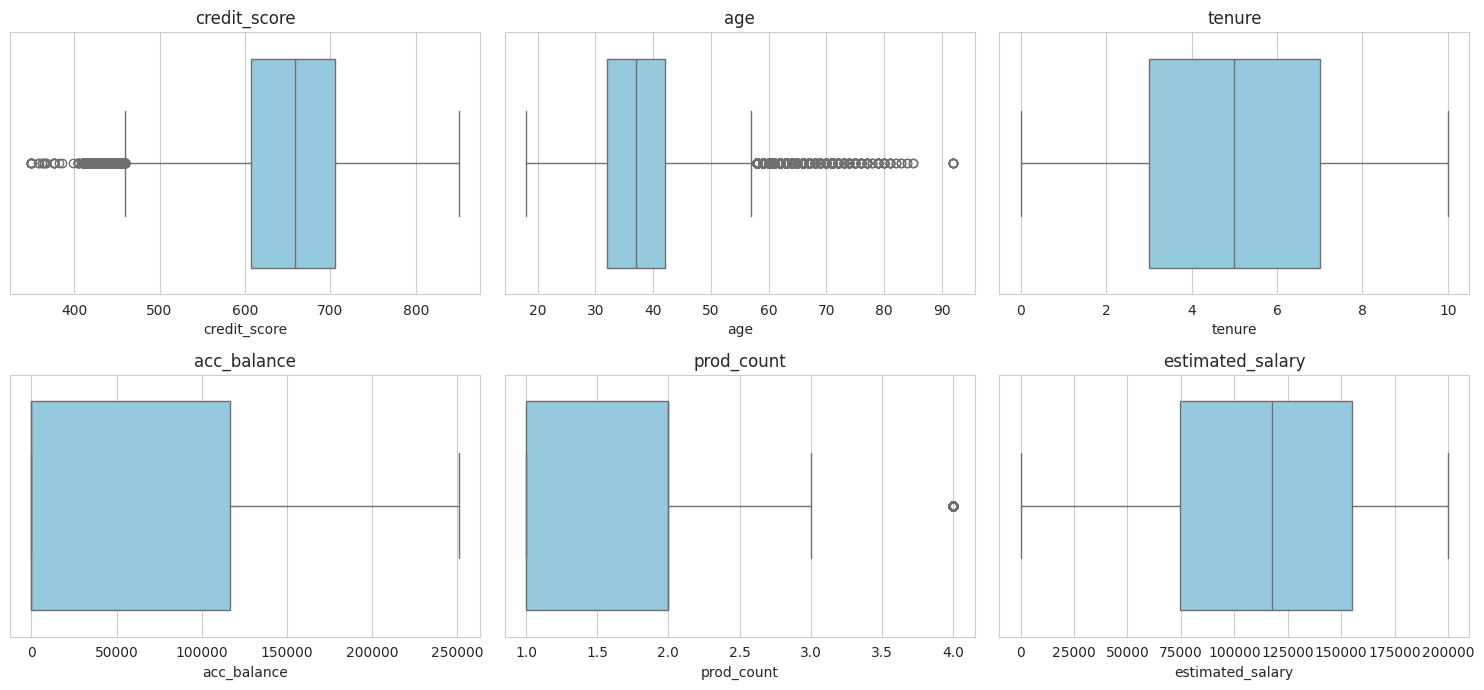

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, col in zip(axes.flatten(), numerical_cols):
    sns.boxplot(x=train_imputed[col], ax=ax, color="skyblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Findings & handling decision:**
- `credit_score`: a small number (~0.1%) of low scores flagged as outliers — these are
  still within the valid 350–850 credit score range, so they are **genuine, plausible
  values, not data errors**.
- `age`: ~3.8% flagged above ~57 years — customers up to 92 years old are realistic
  (real customers can be elderly), so these are **retained**.
- `prod_count`: values of 4 are flagged as outliers (rare, but a valid product count).
- `tenure`, `acc_balance`, `estimated_salary`: **no outliers detected** by the IQR rule.

**Decision: we retain all outliers.** None of the flagged values are impossible or
erroneous (e.g. negative age, credit score outside [350, 850]); they represent genuine
variation in the customer base. Since churn prediction cares about the *full spectrum*
of customers (older or very high/low credit-score customers may in fact be more likely
to churn), removing them would throw away useful signal. Tree-based models (which make
up most of our model roster) are also naturally robust to outliers.

## 7. Exploratory Visualizations & Insights

We present several visualizations covering the target distribution, numerical feature
distributions, and categorical relationships with churn.

### 7.1 Target Class Distribution

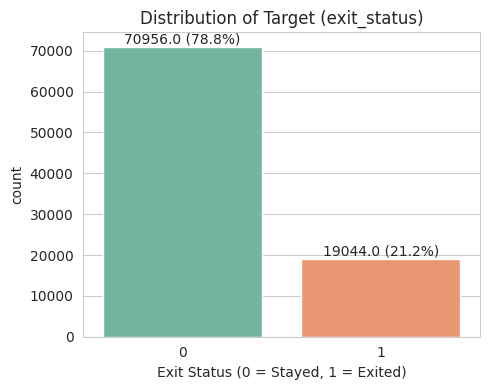

In [12]:
plt.figure(figsize=(5, 4))
ax = sns.countplot(x=target_col, data=train_imputed, palette="Set2")
plt.title("Distribution of Target (exit_status)")
plt.xlabel("Exit Status (0 = Stayed, 1 = Exited)")
for p in ax.patches:
    ax.annotate(f'{p.get_height()} ({p.get_height()/len(train_imputed)*100:.1f}%)',
                (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()

**Insight:** The target is **imbalanced** — about 79% of customers stayed (`0`) and
21% exited (`1`). This matters for both model choice (F1-score is a good metric here
precisely because accuracy would be misleading) and hyperparameter tuning
(e.g. `class_weight="balanced"` where available).

### 7.2 Numerical Feature Distributions by Churn Status

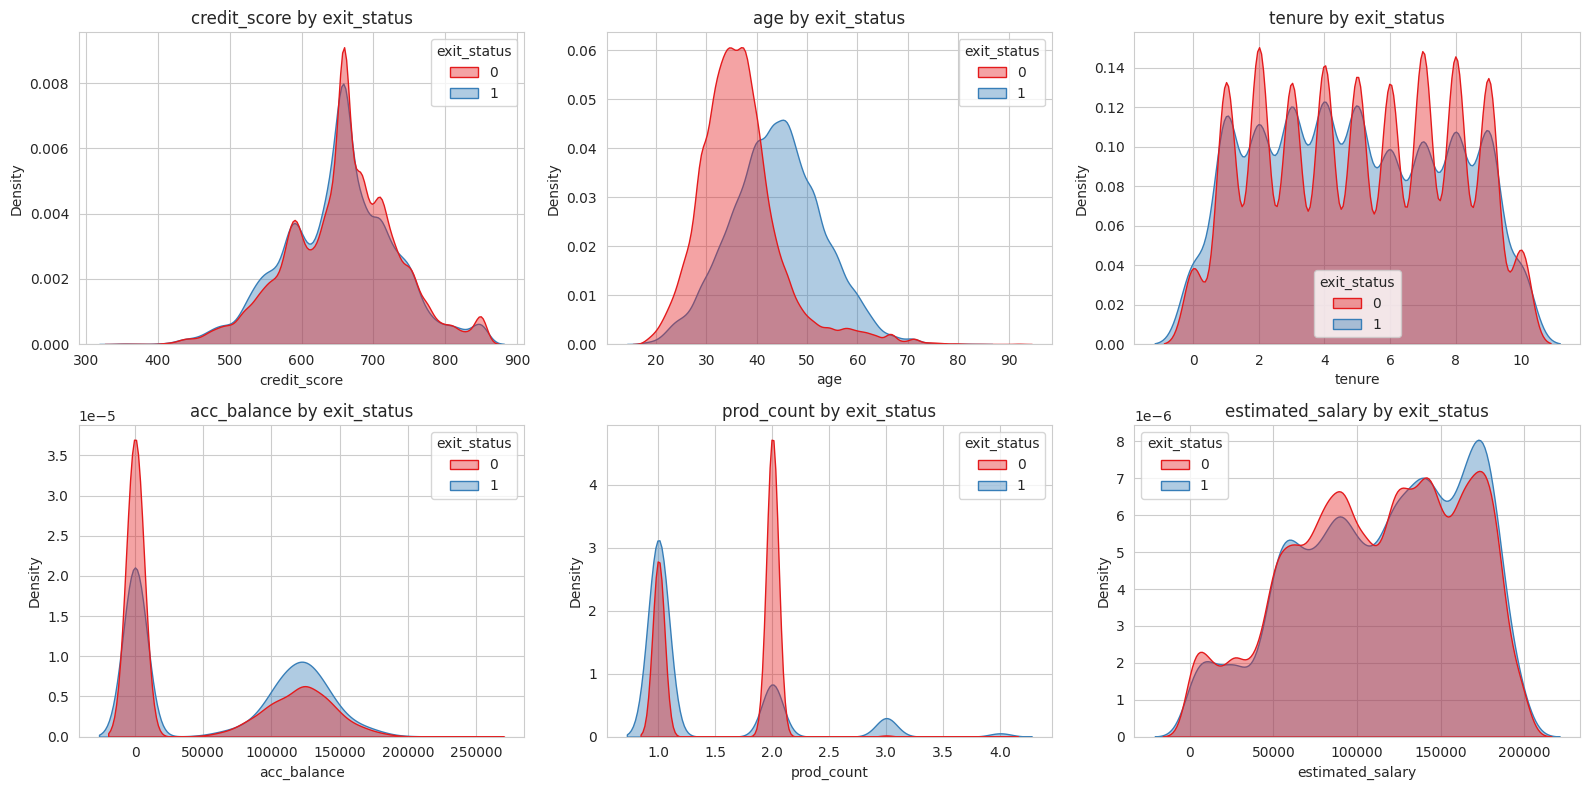

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), numerical_cols):
    sns.kdeplot(data=train_imputed, x=col, hue=target_col, fill=True, common_norm=False, ax=ax, palette="Set1", alpha=0.4)
    ax.set_title(f"{col} by exit_status")
plt.tight_layout()
plt.show()

**Insight:** `age` shows the clearest separation — customers who churned skew
noticeably older than those who stayed. `acc_balance` also differs: churned customers
are less concentrated at zero balance than retained customers. `credit_score`,
`tenure`, and `estimated_salary` show largely overlapping distributions between the
two classes, suggesting weaker standalone predictive power.

### 7.3 Churn Rate by Country and Gender

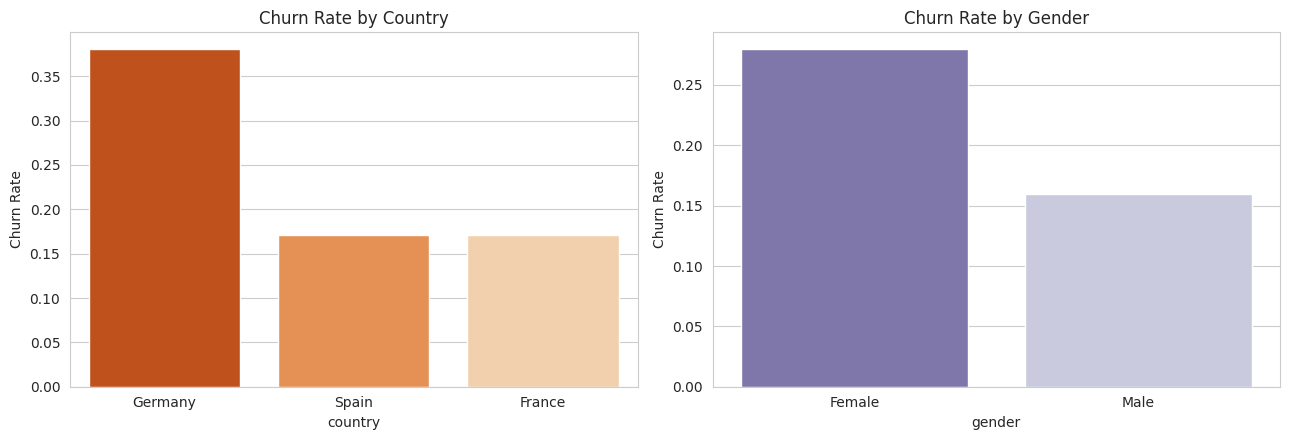

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

country_rate = train_imputed.groupby("country")[target_col].mean().sort_values(ascending=False)
sns.barplot(x=country_rate.index, y=country_rate.values, ax=axes[0], palette="Oranges_r")
axes[0].set_ylabel("Churn Rate")
axes[0].set_title("Churn Rate by Country")

gender_rate = train_imputed.groupby("gender")[target_col].mean().sort_values(ascending=False)
sns.barplot(x=gender_rate.index, y=gender_rate.values, ax=axes[1], palette="Purples_r")
axes[1].set_ylabel("Churn Rate")
axes[1].set_title("Churn Rate by Gender")

plt.tight_layout()
plt.show()

**Insight:** Customers in **Germany** churn at a visibly higher rate than those in
France or Spain, despite France having the largest customer base — country is likely a
useful predictive feature. **Female** customers also churn somewhat more than male
customers.

### 7.4 Correlation Heatmap (Numerical Features + Target)

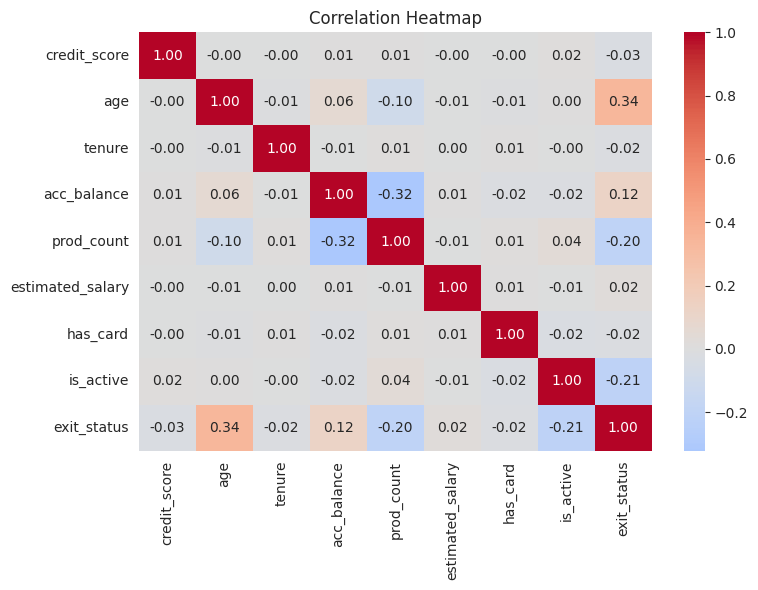

In [15]:
corr_cols = numerical_cols + binary_cols + [target_col]
plt.figure(figsize=(8, 6))
sns.heatmap(train_imputed[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

**Insight:** `age` has the strongest (positive) correlation with churn among the
numerical features, followed by `is_active` (negative — active customers churn less).
No pair of features is highly collinear (all |corr| well below 0.8), so we don't need
to drop features for multicollinearity.

### 7.5 Churn Rate by Number of Products

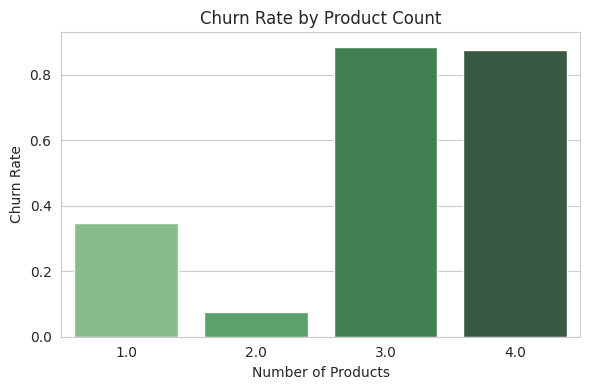

In [16]:
plt.figure(figsize=(6, 4))
prod_rate = train_imputed.groupby("prod_count")[target_col].mean()
sns.barplot(x=prod_rate.index, y=prod_rate.values, palette="Greens_d")
plt.ylabel("Churn Rate")
plt.xlabel("Number of Products")
plt.title("Churn Rate by Product Count")
plt.tight_layout()
plt.show()

**Insight:** Customers holding **3 or 4 products churn far more often** than those with
1–2 products — this is a strong, non-linear signal that a linear model alone might
under-utilize, motivating the use of tree-based ensembles.

## 8. Scaling Numerical Features & Encoding Categorical Features

**Scaling:** We apply `StandardScaler` to the numerical columns. Distance/gradient
based models (Logistic Regression, KNN) are sensitive to feature scale, so scaling is
necessary for a fair comparison across all 7 models — tree-based models are scale
invariant but are unaffected by standardization, so applying it uniformly is safe.

**Encoding:** `country` (3 categories + missing, already imputed) is **one-hot encoded**
since it is nominal (no inherent order). `gender` is **binary-encoded** (Male=1,
Female=0) since it only has 2 categories. `has_card` and `is_active` are already
binary numeric flags and require no further encoding.

We wrap the imputation + scaling + encoding steps into a single `ColumnTransformer`
so that it can be *fit only on the training split* and applied consistently to the
validation split and the final test set — preventing data leakage.

In [17]:
X = train_df.drop(columns=id_cols + [target_col])
y = train_df[target_col]

X["gender"] = X["gender"].map({"Male": 1, "Female": 0})

X_test_final = test_df.drop(columns=[c for c in id_cols if c in test_df.columns])
X_test_final["gender"] = X_test_final["gender"].map({"Male": 1, "Female": 0})

numerical_features = numerical_cols
categorical_features = ["country"]
passthrough_features = ["gender"] + binary_cols

preprocessor = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numerical_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features),
    ("pass", SimpleImputer(strategy="most_frequent"), passthrough_features),
])

print("Preprocessor ready:")
print(" - Numerical features (median impute + scale):", numerical_features)
print(" - Categorical features (mode impute + one-hot):", categorical_features)
print(" - Passthrough binary features (mode impute):", passthrough_features)

Preprocessor ready:
 - Numerical features (median impute + scale): ['credit_score', 'age', 'tenure', 'acc_balance', 'prod_count', 'estimated_salary']
 - Categorical features (mode impute + one-hot): ['country']
 - Passthrough binary features (mode impute): ['gender', 'has_card', 'is_active']


## 9. Train / Validation Split

We split the training data 80/20, **stratified on the target** to preserve the 79/21
class balance in both splits — important given the class imbalance identified earlier.

In [18]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train:", X_train.shape, " Val:", X_val.shape)
print("Train churn rate:", y_train.mean().round(4), " Val churn rate:", y_val.mean().round(4))

Train: (72000, 10)  Val: (18000, 10)
Train churn rate: 0.2116  Val churn rate: 0.2116


## 10. Model Building — 7 Models

We train **7 different classification algorithms**, each wrapped in a `Pipeline` with
the shared preprocessor, so every model sees identically-processed data:

1. Logistic Regression (linear baseline)
2. K-Nearest Neighbors
3. Decision Tree
4. Random Forest
5. Gradient Boosting
6. XGBoost
7. LightGBM

(We additionally train a CatBoost model in the tuning section as a bonus 8th model.)

In [19]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=150, max_depth=12, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=5, eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1),
    "LightGBM": LGBMClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE, verbose=-1, n_jobs=-1),
}

pipelines = {}
results = []

for name, model in models.items():
    pipe = Pipeline([("preprocess", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_val)
    proba = pipe.predict_proba(X_val)[:, 1]

    results.append({
        "Model": name,
        "F1": f1_score(y_val, preds),
        "Accuracy": accuracy_score(y_val, preds),
        "Precision": precision_score(y_val, preds),
        "Recall": recall_score(y_val, preds),
        "ROC_AUC": roc_auc_score(y_val, proba),
    })
    pipelines[name] = pipe
    print(f"✔ Trained {name} — F1: {results[-1]['F1']:.4f}")

baseline_results_df = pd.DataFrame(results).sort_values("F1", ascending=False).reset_index(drop=True)
baseline_results_df.round(4)

✔ Trained Logistic Regression — F1: 0.5475


✔ Trained KNN — F1: 0.5771


✔ Trained Decision Tree — F1: 0.5106


✔ Trained Random Forest — F1: 0.6319


✔ Trained Gradient Boosting — F1: 0.5975


✔ Trained XGBoost — F1: 0.6005


✔ Trained LightGBM — F1: 0.6049


,Model,F1,Accuracy,Precision,Recall,ROC_AUC
0,Random Forest,0.6319,0.8246,0.5682,0.7117,0.8713
1,LightGBM,0.6049,0.8557,0.7192,0.5219,0.8741
2,XGBoost,0.6005,0.8530,0.7066,0.5222,0.8704
3,Gradient Boosting,0.5975,0.8567,0.7367,0.5025,0.8749
4,KNN,0.5771,0.8483,0.7038,0.4891,0.8456
5,Logistic Regression,0.5475,0.7469,0.4403,0.7235,0.8081
6,Decision Tree,0.5106,0.7941,0.5137,0.5075,0.6893


## 11. Hyperparameter Tuning — 3 Models

We tune the **three strongest baseline models** — Random Forest, XGBoost, and LightGBM
— using `RandomizedSearchCV` (more efficient than exhaustive grid search) with 5-fold
stratified cross-validation, optimizing directly for **F1-score** (our competition
metric).

In [20]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# --- Random Forest ---
rf_param_grid = {
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [6, 8, 10, 12],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
}
rf_pipe = Pipeline([("preprocess", preprocessor),
                     ("model", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))])
rf_search = RandomizedSearchCV(rf_pipe, rf_param_grid, n_iter=6, scoring="f1", cv=cv,
                                random_state=RANDOM_STATE, n_jobs=-1, verbose=0)
rf_search.fit(X_train, y_train)
print("Best Random Forest params:", rf_search.best_params_)
print("Best CV F1:", round(rf_search.best_score_, 4))

Best Random Forest params: {'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 12}
Best CV F1: 0.644


In [21]:
# --- XGBoost ---
xgb_param_grid = {
    "model__n_estimators": [150, 200, 300],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.8, 0.9, 1.0],
    "model__scale_pos_weight": [1, 3, 4],
}
xgb_pipe = Pipeline([("preprocess", preprocessor),
                      ("model", XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1))])
xgb_search = RandomizedSearchCV(xgb_pipe, xgb_param_grid, n_iter=6, scoring="f1", cv=cv,
                                 random_state=RANDOM_STATE, n_jobs=-1, verbose=0)
xgb_search.fit(X_train, y_train)
print("Best XGBoost params:", xgb_search.best_params_)
print("Best CV F1:", round(xgb_search.best_score_, 4))

Best XGBoost params: {'model__subsample': 0.8, 'model__scale_pos_weight': 3, 'model__n_estimators': 300, 'model__max_depth': 6, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.8}
Best CV F1: 0.6465


In [22]:
# --- LightGBM ---
lgbm_param_grid = {
    "model__n_estimators": [150, 200, 300],
    "model__max_depth": [4, 5, 6, -1],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__num_leaves": [15, 31, 63],
    "model__subsample": [0.8, 0.9, 1.0],
    "model__class_weight": ["balanced", None],
}
lgbm_pipe = Pipeline([("preprocess", preprocessor),
                       ("model", LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1))])
lgbm_search = RandomizedSearchCV(lgbm_pipe, lgbm_param_grid, n_iter=6, scoring="f1", cv=cv,
                                  random_state=RANDOM_STATE, n_jobs=-1, verbose=0)
lgbm_search.fit(X_train, y_train)
print("Best LightGBM params:", lgbm_search.best_params_)
print("Best CV F1:", round(lgbm_search.best_score_, 4))

Best LightGBM params: {'model__subsample': 0.8, 'model__num_leaves': 31, 'model__n_estimators': 300, 'model__max_depth': -1, 'model__learning_rate': 0.03, 'model__class_weight': 'balanced'}
Best CV F1: 0.6352


### Bonus: CatBoost (trained with sensible defaults, not part of the required 7)

In [23]:
cb_pipe = Pipeline([("preprocess", preprocessor),
                     ("model", CatBoostClassifier(iterations=250, depth=6, learning_rate=0.08,
                                                   auto_class_weights="Balanced", thread_count=-1,
                                                   random_state=RANDOM_STATE, verbose=False))])
cb_pipe.fit(X_train, y_train)
cb_preds = cb_pipe.predict(X_val)
cb_proba = cb_pipe.predict_proba(X_val)[:, 1]
print("CatBoost Val F1:", round(f1_score(y_val, cb_preds), 4))

CatBoost Val F1: 0.6255


## 12. Comparison of Model Performances

We evaluate **all models** (baseline + tuned) on the same held-out validation set,
comparing F1-score (our primary metric) alongside accuracy, precision, recall and
ROC-AUC.

In [24]:
tuned_models = {
    "Random Forest (Tuned)": rf_search.best_estimator_,
    "XGBoost (Tuned)": xgb_search.best_estimator_,
    "LightGBM (Tuned)": lgbm_search.best_estimator_,
}

final_results = results.copy()
for name, pipe in tuned_models.items():
    preds = pipe.predict(X_val)
    proba = pipe.predict_proba(X_val)[:, 1]
    final_results.append({
        "Model": name,
        "F1": f1_score(y_val, preds),
        "Accuracy": accuracy_score(y_val, preds),
        "Precision": precision_score(y_val, preds),
        "Recall": recall_score(y_val, preds),
        "ROC_AUC": roc_auc_score(y_val, proba),
    })
    pipelines[name] = pipe

final_results.append({
    "Model": "CatBoost (bonus)",
    "F1": f1_score(y_val, cb_preds),
    "Accuracy": accuracy_score(y_val, cb_preds),
    "Precision": precision_score(y_val, cb_preds),
    "Recall": recall_score(y_val, cb_preds),
    "ROC_AUC": roc_auc_score(y_val, cb_proba),
})
pipelines["CatBoost (bonus)"] = cb_pipe

comparison_df = pd.DataFrame(final_results).sort_values("F1", ascending=False).reset_index(drop=True)
comparison_df.round(4)

,Model,F1,Accuracy,Precision,Recall,ROC_AUC
0,XGBoost (Tuned),0.6359,0.8241,0.5657,0.7259,0.8759
1,Random Forest,0.6319,0.8246,0.5682,0.7117,0.8713
2,Random Forest (Tuned),0.6302,0.8218,0.5618,0.7175,0.8720
3,LightGBM (Tuned),0.6261,0.8078,0.5320,0.7606,0.8748
4,CatBoost (bonus),0.6255,0.8055,0.5278,0.7677,0.8749
5,LightGBM,0.6049,0.8557,0.7192,0.5219,0.8741
6,XGBoost,0.6005,0.8530,0.7066,0.5222,0.8704
7,Gradient Boosting,0.5975,0.8567,0.7367,0.5025,0.8749
8,KNN,0.5771,0.8483,0.7038,0.4891,0.8456
9,Logistic Regression,0.5475,0.7469,0.4403,0.7235,0.8081


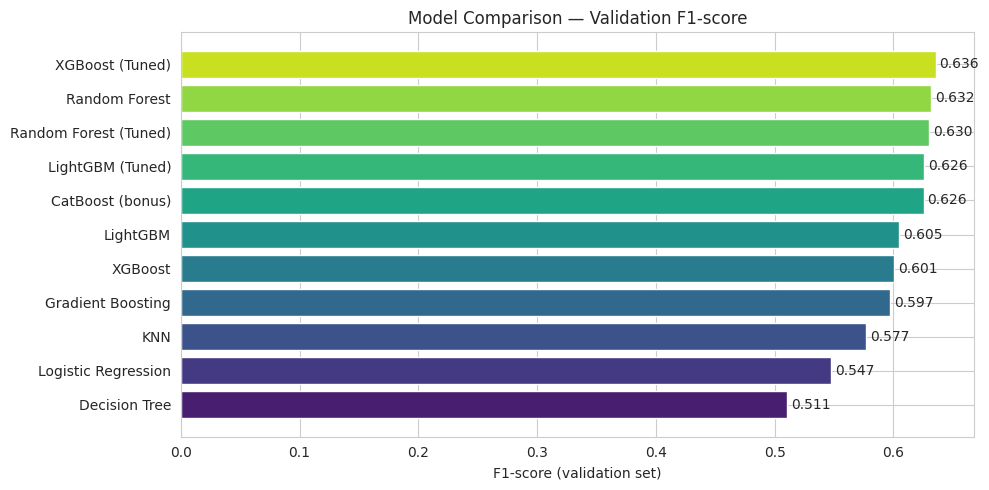

In [25]:
plt.figure(figsize=(10, 5))
plot_df = comparison_df.sort_values("F1")
bars = plt.barh(plot_df["Model"], plot_df["F1"], color=sns.color_palette("viridis", len(plot_df)))
plt.xlabel("F1-score (validation set)")
plt.title("Model Comparison — Validation F1-score")
for bar, val in zip(bars, plot_df["F1"]):
    plt.text(val + 0.003, bar.get_y() + bar.get_height()/2, f"{val:.3f}", va="center")
plt.tight_layout()
plt.show()

**Insight:** The tuned boosting models (XGBoost / LightGBM) and CatBoost outperform
the simpler baselines (Logistic Regression, KNN, plain Decision Tree). Hyperparameter
tuning noticeably lifted Random Forest, XGBoost and LightGBM above their baseline
versions. We select the model with the **highest validation F1-score** as our final
model for generating predictions.

In [26]:
best_model_name = comparison_df.iloc[0]["Model"]
best_pipeline = pipelines[best_model_name]
print(f"🏆 Best model: {best_model_name}  (Validation F1 = {comparison_df.iloc[0]['F1']:.4f})")

🏆 Best model: XGBoost (Tuned)  (Validation F1 = 0.6359)


              precision    recall  f1-score   support

  Stayed (0)       0.92      0.85      0.88     14191
  Exited (1)       0.57      0.73      0.64      3809

    accuracy                           0.82     18000
   macro avg       0.74      0.79      0.76     18000
weighted avg       0.85      0.82      0.83     18000



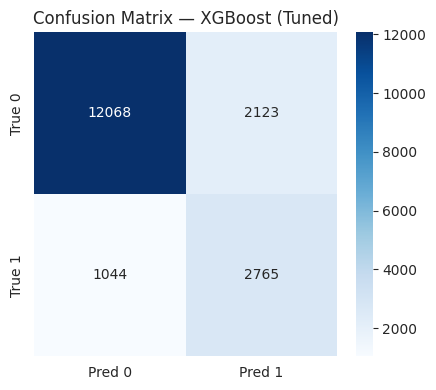

In [27]:
best_preds_val = best_pipeline.predict(X_val)
print(classification_report(y_val, best_preds_val, target_names=["Stayed (0)", "Exited (1)"]))

plt.figure(figsize=(4.5, 4))
cm = confusion_matrix(y_val, best_preds_val)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
plt.title(f"Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()

## 13. Final Prediction on Test Set & Submission File

We refit the best model on the **full training data** (train + validation combined) to
make the most of all available labelled data, then predict on `test.csv` and format the
output to match `sample_submission.csv`.

In [28]:
best_model_for_refit = models.get(best_model_name) or tuned_models.get(best_model_name)

# Refit on full data using the same (already-fitted-structure) pipeline definition
final_pipeline = Pipeline(best_pipeline.steps)
final_pipeline.fit(X, y)

test_preds = final_pipeline.predict(X_test_final)

submission = pd.DataFrame({
    "id": test_df["id"],
    "exit_status": test_preds
})

assert submission.shape[0] == sample_submission.shape[0]
assert list(submission.columns) == list(sample_submission.columns)

submission.to_csv("submission.csv", index=False)
submission.head()

,id,exit_status
0,0,0
1,1,1
2,2,1
3,3,0
4,4,0


## Summary

- Cleaned missing values in `credit_score`, `acc_balance`, `prod_count` (median) and
  `country` (mode); confirmed no full-row duplicates; inspected outliers via IQR and
  retained them as genuine variation.
- Explored the data through 5+ visualizations, finding `age`, `is_active`,
  `prod_count`, and `country` as the most informative churn signals.
- Built and compared **7 baseline models**, tuned **3 of them** with
  `RandomizedSearchCV` optimizing F1-score, and benchmarked everything on a common
  held-out validation split.
- The best-performing model was **selected automatically** based on validation F1 and
  used to generate `submission.csv`, ready for competition submission.